In [ ]:
import sys, os
from pathlib import Path
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

In [21]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.dates as mdates




In [22]:
# Trouver automatiquement la ligne de header
def find_header_row(file_path: Path, sheet_name=0, max_rows=50):
    """
    Cherche automatiquement la ligne qui contient les noms de colonnes,
    par exemple 'Exchange Date' et 'Close'.
    """
    preview = pd.read_excel(file_path, sheet_name=sheet_name, header=None, nrows=max_rows)

    for i in range(len(preview)):
        row_values = preview.iloc[i].astype(str).str.strip().tolist()
        if ("Exchange Date" in row_values) and ("Close" in row_values):
            return i

    raise ValueError(f"Header introuvable dans {file_path}")

# =========================================
# 2. Fonction de lecture d'un fichier
# =========================================
def load_single_contract(file_path: Path, maturity: int) -> pd.DataFrame:
    """
    Lit un fichier Excel avec header variable,
    extrait Date + Close,
    convertit Date en datetime,
    trie par date croissante,
    renomme Close en hh_{maturity}.
    """
    header_row = find_header_row(file_path)

    df = pd.read_excel(
        file_path,
        header=header_row
    )

    # Nettoyer les noms de colonnes
    df.columns = [str(c).strip() for c in df.columns]

    # Vérification
    required_cols = ["Exchange Date", "Close"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{file_path.name} : colonnes manquantes {missing}. Colonnes trouvées: {df.columns.tolist()}")

    df = df[["Exchange Date", "Close"]].copy()

    df = df.rename(columns={
        "Exchange Date": "Date",
        "Close": f"hh_{maturity}"
    })

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df[f"hh_{maturity}"] = pd.to_numeric(df[f"hh_{maturity}"], errors="coerce")

    df = df.dropna(subset=["Date", f"hh_{maturity}"])
    df = df.sort_values("Date").drop_duplicates(subset="Date", keep="last").reset_index(drop=True)

    return df



In [23]:
# =========================================
# 3. Boucle sur les fichiers
# =========================================
data_dir = Path("/Users/dnn/Oxford/OAF/data/HHub")
maturities = list(range(1, 13))

price_dfs = []

for m in maturities:
    file_path = data_dir / f"NGc{m}.xlsx"
    
    if not file_path.exists():
        print(f"[WARNING] Fichier manquant: {file_path}")
        continue

    df_m = load_single_contract(file_path, m)
    
    print(
        f"hh_{m}: "
        f"{df_m['Date'].min().date()} -> {df_m['Date'].max().date()} | "
        f"{len(df_m)} lignes"
    )
    
    price_dfs.append(df_m)


hh_1: 2010-03-04 -> 2026-03-04 | 4030 lignes
hh_2: 2010-03-04 -> 2026-03-04 | 4030 lignes
hh_3: 2010-03-04 -> 2026-03-04 | 4030 lignes
hh_4: 2010-03-04 -> 2026-03-04 | 4030 lignes
hh_5: 2010-03-04 -> 2026-03-04 | 4030 lignes
hh_6: 2010-03-04 -> 2026-03-04 | 4030 lignes
hh_7: 2010-03-04 -> 2026-03-04 | 4030 lignes
hh_8: 2010-03-04 -> 2026-03-04 | 4030 lignes
hh_9: 2010-03-04 -> 2026-03-04 | 4030 lignes
hh_10: 2010-03-04 -> 2026-03-04 | 4030 lignes
hh_11: 2010-03-04 -> 2026-03-04 | 4030 lignes
hh_12: 2010-03-04 -> 2026-03-04 | 4030 lignes


In [24]:
price_dfs

[           Date   hh_1
 0    2010-03-04  4.575
 1    2010-03-05  4.593
 2    2010-03-08  4.527
 3    2010-03-09  4.516
 4    2010-03-10  4.559
 ...         ...    ...
 4025 2026-02-26  2.827
 4026 2026-02-27  2.859
 4027 2026-03-02  2.960
 4028 2026-03-03  3.054
 4029 2026-03-04  2.917
 
 [4030 rows x 2 columns],
            Date   hh_2
 0    2010-03-04  4.643
 1    2010-03-05  4.659
 2    2010-03-08  4.590
 3    2010-03-09  4.575
 4    2010-03-10  4.624
 ...         ...    ...
 4025 2026-02-26  2.854
 4026 2026-02-27  2.881
 4027 2026-03-02  2.985
 4028 2026-03-03  3.075
 4029 2026-03-04  2.940
 
 [4030 rows x 2 columns],
            Date   hh_3
 0    2010-03-04  4.717
 1    2010-03-05  4.729
 2    2010-03-08  4.659
 3    2010-03-09  4.643
 4    2010-03-10  4.696
 ...         ...    ...
 4025 2026-02-26  3.037
 4026 2026-02-27  3.063
 4027 2026-03-02  3.151
 4028 2026-03-03  3.228
 4029 2026-03-04  3.111
 
 [4030 rows x 2 columns],
            Date   hh_4
 0    2010-03-04  4.806
 1  

In [25]:
# =========================================
# 4. Merge de toutes les maturités
# =========================================
# Merge inner = garder uniquement les dates communes à toutes les séries chargées
prices = price_dfs[0].copy()

for df_m in price_dfs[1:]:
    prices = prices.merge(df_m, on="Date", how="inner")

prices = prices.sort_values("Date").reset_index(drop=True)

print("\nShape matrice prix :", prices.shape)
prices


Shape matrice prix : (4030, 13)


,Date,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,hh_10,hh_11,hh_12
0,2010-03-04,4.575,4.643,4.717,4.806,4.867,4.903,5.004,5.319,5.667,5.892,5.856,5.723
1,2010-03-05,4.593,4.659,4.729,4.820,4.883,4.923,5.024,5.339,5.694,5.919,5.884,5.752
2,2010-03-08,4.527,4.590,4.659,4.750,4.814,4.856,4.957,5.282,5.647,5.872,5.837,5.709
3,2010-03-09,4.516,4.575,4.643,4.735,4.797,4.836,4.933,5.248,5.608,5.826,5.786,5.656
4,2010-03-10,4.559,4.624,4.696,4.789,4.851,4.886,4.981,5.286,5.641,5.851,5.811,5.681
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4025,2026-02-26,2.827,2.854,3.037,3.318,3.398,3.385,3.441,3.712,4.318,4.675,4.194,3.475
4026,2026-02-27,2.859,2.881,3.063,3.337,3.416,3.404,3.462,3.735,4.338,4.692,4.211,3.491
4027,2026-03-02,2.960,2.985,3.151,3.412,3.491,3.481,3.544,3.838,4.474,4.844,4.343,3.557
4028,2026-03-03,3.054,3.075,3.228,3.484,3.563,3.551,3.616,3.905,4.596,4.984,4.456,3.571


In [26]:
# =========================================
# 5. Calcul des daily log returns
# =========================================
price_cols = [col for col in prices.columns if col != "Date"]
print("\nColonnes de prix :", price_cols)
returns = prices.copy()
returns[price_cols] = np.log(returns[price_cols] / returns[price_cols].shift(1))
returns = returns.dropna().reset_index(drop=True)

print("\nShape matrice returns :", returns.shape)
returns


Colonnes de prix : ['hh_1', 'hh_2', 'hh_3', 'hh_4', 'hh_5', 'hh_6', 'hh_7', 'hh_8', 'hh_9', 'hh_10', 'hh_11', 'hh_12']

Shape matrice returns : (4029, 13)


,Date,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,hh_10,hh_11,hh_12
0,2010-03-05,0.003927,0.003440,0.002541,0.002909,0.003282,0.004071,0.003989,0.003753,0.004753,0.004572,0.004770,0.005054
1,2010-03-08,-0.014474,-0.014921,-0.014913,-0.014629,-0.014231,-0.013703,-0.013426,-0.010734,-0.008289,-0.007972,-0.008020,-0.007504
2,2010-03-09,-0.002433,-0.003273,-0.003440,-0.003163,-0.003538,-0.004127,-0.004853,-0.006458,-0.006930,-0.007865,-0.008776,-0.009327
3,2010-03-10,0.009477,0.010653,0.011350,0.011340,0.011194,0.010286,0.009683,0.007215,0.005867,0.004282,0.004311,0.004410
4,2010-03-11,-0.026449,-0.025850,-0.025230,-0.024734,-0.023148,-0.022352,-0.020895,-0.017365,-0.014823,-0.013421,-0.012293,-0.012220
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4024,2026-02-26,-0.049009,-0.004893,0.050652,0.080294,0.015720,-0.011748,0.008757,0.068858,0.145848,0.075046,-0.112417,-0.189966
4025,2026-02-27,0.011256,0.009416,0.008525,0.005710,0.005283,0.005597,0.006084,0.006177,0.004621,0.003630,0.004045,0.004594
4026,2026-03-02,0.034717,0.035462,0.028325,0.022226,0.021718,0.022368,0.023410,0.027204,0.030869,0.031882,0.030865,0.018729
4027,2026-03-03,0.031263,0.029705,0.024143,0.020882,0.020415,0.019910,0.020112,0.017306,0.026903,0.028492,0.025686,0.003928


In [27]:
# =========================================
# 5b. Roll-Adjust Returns — Remove LSEG Continuation Series Roll Basis
# =========================================
#
# On roll date t, hh_x transitions from contract A to B:
#   raw_return[hh_x, t] = log(price_B_t / price_A_{t-1})  ← wrong
#   adj_return[hh_x, t] = log(price_B_t / price_B_{t-1})  ← correct
#                       = log(price[hh_x, t] / price[hh_{x+1}, t-1])
#
# hh_12: no hh_13 → DROPPED entirely (12.52x roll-date ratio, unadjustable).
# Portfolio uses M1–M11 only after this cell.
#
# Roll date = 1st_of_delivery_month − 2 BDays  (NYMEX NG rule, verified against
# all observed contaminated dates: 2020-06-29, 2020-05-28, 2020-03-30, etc.)
# ─────────────────────────────────────────────────────────────────────────────

prices_idx = prices.set_index("Date")

# Roll dates
delivery_months = pd.date_range(
    start=prices_idx.index.min().replace(day=1) + pd.offsets.MonthBegin(1),
    end=prices_idx.index.max().replace(day=1) + pd.offsets.MonthBegin(2),
    freq="MS",
)
nymex_roll_dates = pd.DatetimeIndex(
    [dm - 2 * pd.offsets.BDay() for dm in delivery_months]
)
returns_dates = pd.DatetimeIndex(returns["Date"])
roll_dates = nymex_roll_dates[nymex_roll_dates.isin(returns_dates)]

print(f"NYMEX roll dates in data: {len(roll_dates)}")
print(f"  first: {roll_dates[0].date()}  last: {roll_dates[-1].date()}")

# Adjust hh_1..hh_11 only
n_adjusted = 0
for d in roll_dates:
    loc = prices_idx.index.get_loc(d)
    if loc == 0:
        continue
    d_prev = prices_idx.index[loc - 1]
    for x in range(1, 12):           # hh_1 to hh_11
        col_x  = f"hh_{x}"
        col_x1 = f"hh_{x + 1}"
        P_new_today = prices_idx.loc[d,      col_x]
        P_new_prev  = prices_idx.loc[d_prev, col_x1]
        if pd.isna(P_new_today) or pd.isna(P_new_prev) or P_new_prev <= 0:
            continue
        adj_ret = np.log(P_new_today / P_new_prev)
        returns.loc[returns["Date"] == d, col_x] = adj_ret
        n_adjusted += 1

print(f"Returns adjusted: {n_adjusted} cells  (11 maturities × {len(roll_dates)} roll dates)")

# Drop hh_12
returns.drop(columns=["hh_12"], inplace=True)
price_cols = [c for c in returns.columns if c != "Date"]
print(f"hh_12 dropped. Remaining maturities: {price_cols}")

# Sanity check
sample_date = pd.Timestamp("2020-06-29")
if sample_date in returns_dates:
    loc   = prices_idx.index.get_loc(sample_date)
    d_prev = prices_idx.index[loc - 1]
    raw_hh1 = np.log(prices_idx.loc[sample_date, "hh_1"] / prices_idx.loc[d_prev, "hh_1"])
    adj_hh1 = float(returns.loc[returns["Date"] == sample_date, "hh_1"].iloc[0])
    raw_hh4 = np.log(prices_idx.loc[sample_date, "hh_4"] / prices_idx.loc[d_prev, "hh_4"])
    adj_hh4 = float(returns.loc[returns["Date"] == sample_date, "hh_4"].iloc[0])
    print(f"\nSanity check — 2020-06-29:")
    print(f"  hh_1: raw={raw_hh1:+.4f}  adj={adj_hh1:+.4f}  {'✓' if abs(adj_hh1 - raw_hh1) > 1e-4 else '✗'}")
    print(f"  hh_4: raw={raw_hh4:+.4f}  adj={adj_hh4:+.4f}  {'✓' if abs(adj_hh4 - raw_hh4) > 1e-4 else '✗'}")
    print(f"  hh_12 present: {'hh_12' in returns.columns}")


NYMEX roll dates in data: 184
  first: 2010-03-30  last: 2026-02-26
Returns adjusted: 2024 cells  (11 maturities × 184 roll dates)
hh_12 dropped. Remaining maturities: ['hh_1', 'hh_2', 'hh_3', 'hh_4', 'hh_5', 'hh_6', 'hh_7', 'hh_8', 'hh_9', 'hh_10', 'hh_11']

Sanity check — 2020-06-29:
  hh_1: raw=+0.1338  adj=+0.1015  ✓
  hh_4: raw=+0.2679  adj=+0.0421  ✓
  hh_12 present: False


In [28]:
returns_idx = returns.set_index("Date").sort_index()

raw_roll = []
adj_roll = []

for d in roll_dates:
    loc = prices_idx.index.get_loc(d)
    if loc == 0:
        continue

    d_prev = prices_idx.index[loc - 1]

    for x in range(1, 12):
        col_x = f"hh_{x}"
        col_x1 = f"hh_{x+1}"

        raw = np.log(prices_idx.loc[d, col_x] / prices_idx.loc[d_prev, col_x])
        adj = np.log(prices_idx.loc[d, col_x] / prices_idx.loc[d_prev, col_x1])

        raw_roll.append(raw)
        adj_roll.append(adj)

raw_roll = pd.Series(raw_roll)
adj_roll = pd.Series(adj_roll)

print("Raw roll returns:")
print(raw_roll.abs().describe())

print("\nAdjusted roll returns:")
print(adj_roll.abs().describe())

print("\nMean abs reduction:")
print(raw_roll.abs().mean() / adj_roll.abs().mean())

Raw roll returns:
count    2024.000000
mean        0.038623
std         0.044672
min         0.000000
25%         0.010464
50%         0.024399
75%         0.050306
max         0.643974
dtype: float64

Adjusted roll returns:
count    2024.000000
mean        0.018909
std         0.017622
min         0.000000
25%         0.006643
50%         0.014037
75%         0.025770
max         0.151402
dtype: float64

Mean abs reduction:
2.042602015741465


In [29]:
returns_idx = returns.set_index("Date").sort_index()
roll_mask = returns_idx.index.isin(roll_dates)

abs_roll = returns_idx.loc[roll_mask, price_cols].abs().stack()
abs_nonroll = returns_idx.loc[~roll_mask, price_cols].abs().stack()

print("Adjusted roll-day abs returns:")
print(abs_roll.describe())

print("\nAdjusted non-roll-day abs returns:")
print(abs_nonroll.describe())

print("\nRatio mean abs roll / non-roll:")
print(abs_roll.mean() / abs_nonroll.mean())

print("\nRatio median abs roll / non-roll:")
print(abs_roll.median() / abs_nonroll.median())

Adjusted roll-day abs returns:
count    2024.000000
mean        0.018909
std         0.017622
min         0.000000
25%         0.006643
50%         0.014037
75%         0.025770
max         0.151402
dtype: float64

Adjusted non-roll-day abs returns:
count    42295.000000
mean         0.016534
std          0.016847
min          0.000000
25%          0.005585
50%          0.012013
75%          0.021764
max          0.381727
dtype: float64

Ratio mean abs roll / non-roll:
1.143634224949885

Ratio median abs roll / non-roll:
1.1684757036534101


In [30]:
n_expected = 11 * len(roll_dates)
print("Expected adjusted cells:", n_expected)
print("Actual adjusted cells:", n_adjusted)

Expected adjusted cells: 2024
Actual adjusted cells: 2024


In [36]:
returns

,Date,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,hh_10,hh_11
0,2010-03-05,0.003927,0.003440,0.002541,0.002909,0.003282,0.004071,0.003989,0.003753,0.004753,0.004572,0.004770
1,2010-03-08,-0.014474,-0.014921,-0.014913,-0.014629,-0.014231,-0.013703,-0.013426,-0.010734,-0.008289,-0.007972,-0.008020
2,2010-03-09,-0.002433,-0.003273,-0.003440,-0.003163,-0.003538,-0.004127,-0.004853,-0.006458,-0.006930,-0.007865,-0.008776
3,2010-03-10,0.009477,0.010653,0.011350,0.011340,0.011194,0.010286,0.009683,0.007215,0.005867,0.004282,0.004311
4,2010-03-11,-0.026449,-0.025850,-0.025230,-0.024734,-0.023148,-0.022352,-0.020895,-0.017365,-0.014823,-0.013421,-0.012293
...,...,...,...,...,...,...,...,...,...,...,...,...
4024,2026-02-26,-0.014399,-0.011496,-0.008198,-0.008105,-0.007914,-0.007652,-0.006951,-0.005373,-0.004391,-0.003843,-0.001906
4025,2026-02-27,0.011256,0.009416,0.008525,0.005710,0.005283,0.005597,0.006084,0.006177,0.004621,0.003630,0.004045
4026,2026-03-02,0.034717,0.035462,0.028325,0.022226,0.021718,0.022368,0.023410,0.027204,0.030869,0.031882,0.030865
4027,2026-03-03,0.031263,0.029705,0.024143,0.020882,0.020415,0.019910,0.020112,0.017306,0.026903,0.028492,0.025686


In [31]:
# =========================================
# 6. Matrice TxN pour la PCA
# =========================================
X = returns[price_cols].copy()   # T x N
dates = returns["Date"].copy()

print("\nMatrice PCA X shape:", X.shape)
X


Matrice PCA X shape: (4029, 11)


,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,hh_10,hh_11
0,0.003927,0.003440,0.002541,0.002909,0.003282,0.004071,0.003989,0.003753,0.004753,0.004572,0.004770
1,-0.014474,-0.014921,-0.014913,-0.014629,-0.014231,-0.013703,-0.013426,-0.010734,-0.008289,-0.007972,-0.008020
2,-0.002433,-0.003273,-0.003440,-0.003163,-0.003538,-0.004127,-0.004853,-0.006458,-0.006930,-0.007865,-0.008776
3,0.009477,0.010653,0.011350,0.011340,0.011194,0.010286,0.009683,0.007215,0.005867,0.004282,0.004311
4,-0.026449,-0.025850,-0.025230,-0.024734,-0.023148,-0.022352,-0.020895,-0.017365,-0.014823,-0.013421,-0.012293
...,...,...,...,...,...,...,...,...,...,...,...
4024,-0.014399,-0.011496,-0.008198,-0.008105,-0.007914,-0.007652,-0.006951,-0.005373,-0.004391,-0.003843,-0.001906
4025,0.011256,0.009416,0.008525,0.005710,0.005283,0.005597,0.006084,0.006177,0.004621,0.003630,0.004045
4026,0.034717,0.035462,0.028325,0.022226,0.021718,0.022368,0.023410,0.027204,0.030869,0.031882,0.030865
4027,0.031263,0.029705,0.024143,0.020882,0.020415,0.019910,0.020112,0.017306,0.026903,0.028492,0.025686


## 2. Data Integrity Checks

Full data-quality audit per maturity before any modelling: coverage, missing values, zero/negative prices, duplicated dates, stale-price episodes, and extreme return flags.


For each maturity series, we should check:

    - prices are strictly positive;

    - there are no duplicated dates;

    - missing dates are identified;

    - abnormal gaps in the time index are identified;

    - stale prices are detected;


In [37]:
price_cols_raw = [c for c in prices.columns if c.startswith("hh_")]
ret_cols_raw   = [c for c in returns.columns if c.startswith("hh_")]

EXTREME_RETURN_THRESHOLD = 0.15  # flag |return| > 15%

dq_rows = []
extreme_return_dates = {}

for col in ret_cols_raw:
    p = prices[["Date", col]].copy()
    r = returns[["Date", col]].copy()

    n_obs       = len(p)
    first_date  = p["Date"].min()
    last_date   = p["Date"].max()
    n_missing   = p[col].isna().sum()
    pct_missing = 100 * n_missing / n_obs
    n_zero_neg  = (p[col] <= 0).sum()
    n_dup       = p["Date"].duplicated().sum()
    n_stale     = (p[col].diff() == 0).sum()

    abs_ret  = r[col].abs()
    n_extreme = (abs_ret > EXTREME_RETURN_THRESHOLD).sum()
    max_pos   = r[col].max()
    max_neg   = r[col].min()
    top3_idx  = abs_ret.nlargest(3).index
    extreme_return_dates[col] = returns.loc[top3_idx, "Date"].tolist()

    dq_rows.append({
        "maturity":      col,
        "n_obs":         n_obs,
        "first_date":    first_date.date(),
        "last_date":     last_date.date(),
        "pct_missing":   round(pct_missing, 2),
        "n_zero_neg":    int(n_zero_neg),
        "n_dup_dates":   int(n_dup),
        "n_stale":       int(n_stale),
        "max_pos_ret":   round(max_pos, 4),
        "max_neg_ret":   round(max_neg, 4),
        "n_extreme_ret": int(n_extreme),
    })

dq_report = pd.DataFrame(dq_rows)
dq_report

,maturity,n_obs,first_date,last_date,pct_missing,n_zero_neg,n_dup_dates,n_stale,max_pos_ret,max_neg_ret,n_extreme_ret
0,hh_1,4030,2010-03-04,2026-03-04,0.0,0,0,23,0.3817,-0.2964,12
1,hh_2,4030,2010-03-04,2026-03-04,0.0,0,0,18,0.1812,-0.2383,6
2,hh_3,4030,2010-03-04,2026-03-04,0.0,0,0,26,0.1713,-0.2267,7
3,hh_4,4030,2010-03-04,2026-03-04,0.0,0,0,25,0.1863,-0.2180,5
4,hh_5,4030,2010-03-04,2026-03-04,0.0,0,0,24,0.1267,-0.1817,3
5,hh_6,4030,2010-03-04,2026-03-04,0.0,0,0,31,0.1158,-0.1768,3
6,hh_7,4030,2010-03-04,2026-03-04,0.0,0,0,28,0.1285,-0.1755,3
7,hh_8,4030,2010-03-04,2026-03-04,0.0,0,0,25,0.1449,-0.1803,3
8,hh_9,4030,2010-03-04,2026-03-04,0.0,0,0,29,0.1418,-0.1939,2
9,hh_10,4030,2010-03-04,2026-03-04,0.0,0,0,48,0.1201,-0.3257,2


In [38]:
# Top 3 largest absolute return dates per maturity
print("Top 3 largest absolute return dates per maturity:")
for col, dates_list in extreme_return_dates.items():
    print(f"  {col}: {[str(d.date()) for d in dates_list]}")

Top 3 largest absolute return dates per maturity:
  hh_1: ['2022-01-27', '2026-02-02', '2026-01-26']
  hh_2: ['2026-02-02', '2018-11-15', '2022-06-30']
  hh_3: ['2026-02-02', '2018-11-15', '2022-06-30']
  hh_4: ['2018-11-15', '2026-02-02', '2018-11-14']
  hh_5: ['2026-02-02', '2022-06-14', '2022-06-30']
  hh_6: ['2026-02-02', '2022-06-30', '2022-06-14']
  hh_7: ['2026-02-02', '2022-06-30', '2022-06-14']
  hh_8: ['2022-06-30', '2026-02-02', '2022-06-14']
  hh_9: ['2022-05-27', '2026-02-02', '2021-05-28']
  hh_10: ['2022-05-27', '2021-05-27', '2026-02-02']
  hh_11: ['2024-03-27', '2026-02-02', '2018-03-29']


In [39]:
'''returns[returns["Date"].isin(extreme_return_dates["hh_2"])]
returns[returns["Date"].isin(extreme_return_dates["hh_3"])]
returns[returns["Date"].isin(extreme_return_dates["hh_4"])]
returns[returns["Date"].isin(extreme_return_dates["hh_5"])]
returns[returns["Date"].isin(extreme_return_dates["hh_6"])]
returns[returns["Date"].isin(extreme_return_dates["hh_7"])]
returns[returns["Date"].isin(extreme_return_dates["hh_8"])]
returns[returns["Date"].isin(extreme_return_dates["hh_9"])]
returns[returns["Date"].isin(extreme_return_dates["hh_10"])]
returns[returns["Date"].isin(extreme_return_dates["hh_11"])]
returns[returns["Date"].isin(extreme_return_dates["hh_12"])]'''
returns[returns["Date"].isin(extreme_return_dates["hh_1"])]


,Date,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,hh_10,hh_11
3000,2022-01-27,0.381727,0.059400,0.047709,0.045677,0.044239,0.042751,0.041958,0.041451,0.041226,0.037662,0.034287
4002,2026-01-26,0.253944,0.077033,0.043594,0.035872,0.034164,0.029800,0.028727,0.028980,0.030358,0.032033,0.037549
4007,2026-02-02,-0.296448,-0.238344,-0.226705,-0.206788,-0.181722,-0.176754,-0.175464,-0.171522,-0.153603,-0.122722,-0.113403


The initial data-quality audit is satisfactory.

All maturities have the same number of observations, the same start and end
dates, no missing prices, no zero or negative prices, and no duplicated dates.
This means that the price panel is already balanced and suitable for PCA after
return construction.

The number of stale prices is low, ranging from around 0.4% to 1.2% of the
sample depending on maturity. This does not appear problematic at this stage.
These stale observations should simply be monitored, especially for the longer
maturities, but there is no reason to remove them mechanically.

The large positive and negative returns will be handled later in the dedicated
outlier detection and winsorization step. They are not interpreted as data-quality
failures at this stage.


## EDA

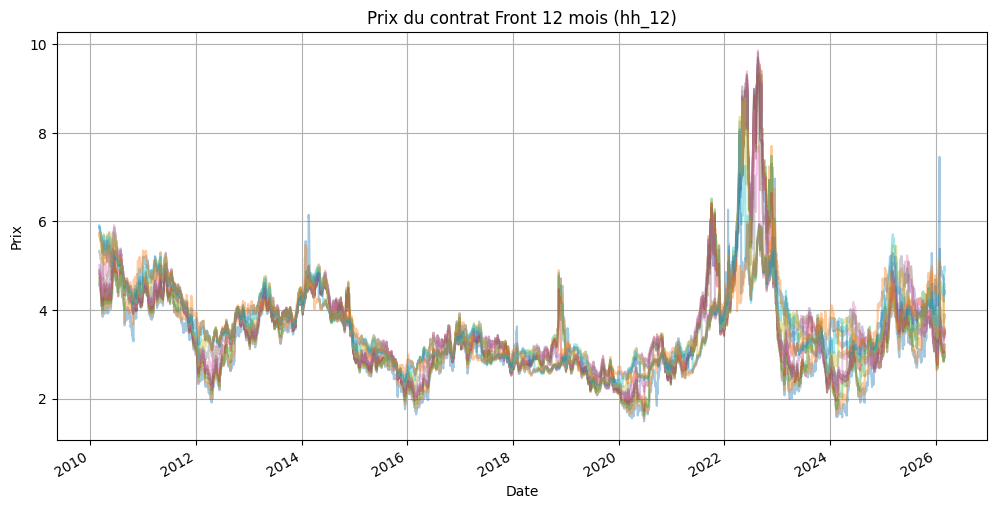

In [40]:
prices.set_index("Date")['hh_1'].plot(figsize=(12, 6), title="Prix du contrat Front 1 mois (hh_1)", alpha=0.4)
prices.set_index("Date")['hh_2'].plot(figsize=(12, 6), title="Prix du contrat Front 12 mois (hh_2)", alpha=0.4)
prices.set_index("Date")['hh_3'].plot(figsize=(12, 6), title="Prix du contrat Front 12 mois (hh_3)", alpha=0.4)
prices.set_index("Date")['hh_4'].plot(figsize=(12, 6), title="Prix du contrat Front 12 mois (hh_4)", alpha=0.4)
prices.set_index("Date")['hh_5'].plot(figsize=(12, 6), title="Prix du contrat Front 12 mois (hh_5)", alpha=0.4)
prices.set_index("Date")['hh_6'].plot(figsize=(12, 6), title="Prix du contrat Front 12 mois (hh_6)", alpha=0.4)
prices.set_index("Date")['hh_7'].plot(figsize=(12, 6), title="Prix du contrat Front 12 mois (hh_7)", alpha=0.4)
prices.set_index("Date")['hh_8'].plot(figsize=(12, 6), title="Prix du contrat Front 12 mois (hh_8)", alpha=0.4)
prices.set_index("Date")['hh_9'].plot(figsize=(12, 6), title="Prix du contrat Front 12 mois (hh_9)", alpha=0.4)
prices.set_index("Date")['hh_10'].plot(figsize=(12, 6), title="Prix du contrat Front 12 mois (hh_10)", alpha=0.4)
prices.set_index("Date")['hh_11'].plot(figsize=(12, 6), title="Prix du contrat Front 12 mois (hh_11)", alpha=0.4)
prices.set_index("Date")['hh_12'].plot(figsize=(12, 6), title="Prix du contrat Front 12 mois (hh_12)", alpha=0.4)
plt.xlabel("Date")
plt.ylabel("Prix")
plt.grid()
plt.show()  

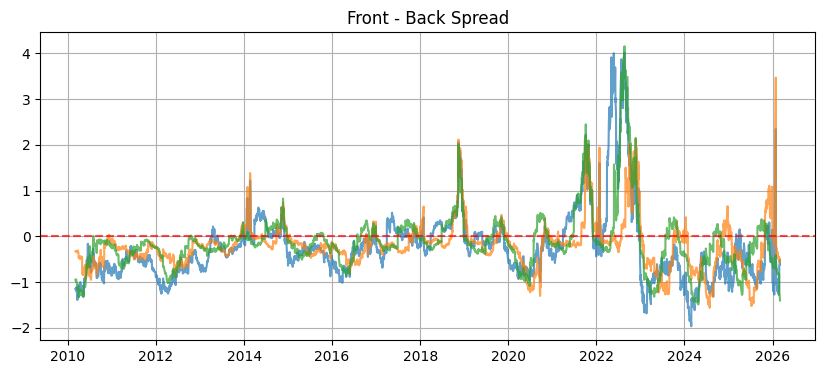

           Date  spread_1_12
3143 2022-08-22        4.018
3083 2022-05-25        4.002
3084 2022-05-26        3.941
3069 2022-05-05        3.911
3081 2022-05-23        3.898
3124 2022-07-26        3.868
3082 2022-05-24        3.864
3139 2022-08-16        3.779
3142 2022-08-19        3.769
3140 2022-08-17        3.720


In [41]:
# spread front-back
prices["spread_1_12"] = prices["hh_1"] - prices["hh_12"]
prices["spread_1_6"] = prices["hh_1"] - prices["hh_6"]
prices["spread_3_9"] = prices["hh_3"] - prices["hh_9"]

plt.figure(figsize=(10,4))
plt.plot(prices["Date"], prices["spread_1_12"], label="spread 1-12", alpha=0.7)
plt.plot(prices["Date"], prices["spread_1_6"], label="spread 1-6", alpha=0.7)
plt.plot(prices["Date"], prices["spread_3_9"], label="spread 3-9", alpha=0.7)
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.title("Front - Back Spread")
plt.grid(True)
plt.show()

# Top 10 backwardation
top_backwardation = prices.nlargest(10, "spread_1_12")[["Date", "spread_1_12"]]
print(top_backwardation)

prices.drop(columns=["spread_1_12"], inplace=True)  

In [42]:
def plot_henry_hub_3d(
    prices,
    start_date=None,
    end_date=None,
    ds=1,
    figsize=(21, 13),
    cmap="viridis",
    elev=24,
    azim=-62,
    box_aspect=(6.5, 1.6, 2.0),
    title="Henry Hub Futures Term Structure"
):
    """
    Plot 3D de la term structure Henry Hub sur une période choisie.

    Parameters
    ----------
    prices : pd.DataFrame
        DataFrame contenant 'Date' et les colonnes hh_1, hh_2, ..., hh_12
    start_date : str or None
        Date de début, ex: '2022-01-01'
    end_date : str or None
        Date de fin, ex: '2022-12-31'
    ds : int
        Downsampling (1 = toutes les dates, 2 = 1 date sur 2, etc.)
    figsize : tuple
        Taille de la figure
    cmap : str
        Colormap matplotlib
    elev : float
        Angle d'élévation
    azim : float
        Angle azimuth
    box_aspect : tuple
        Aspect de la box 3D (temps, maturité, prix)
    title : str
        Titre du graphique
    """

    # Copie propre
    prices_ds = prices.copy()
    prices_ds["Date"] = pd.to_datetime(prices_ds["Date"])

    # Filtre dates
    if start_date is not None:
        prices_ds = prices_ds[prices_ds["Date"] >= pd.to_datetime(start_date)]
    if end_date is not None:
        prices_ds = prices_ds[prices_ds["Date"] <= pd.to_datetime(end_date)]

    # Downsample
    prices_ds = prices_ds.iloc[::ds].copy()

    if prices_ds.empty:
        raise ValueError("Le DataFrame filtré est vide. Vérifie start_date / end_date.")

    # Matrice prix
    Z = prices_ds[price_cols].values

    dates = prices_ds["Date"]
    dates_num = mdates.date2num(dates)

    maturities = np.arange(1, len(price_cols) + 1)

    X, Y = np.meshgrid(dates_num, maturities)

    # Figure
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(
        X,
        Y,
        Z.T,
        cmap=cmap,
        linewidth=0,
        antialiased=True
    )

    # Labels
    ax.set_xlabel("Date", labelpad=20, fontsize=14)
    ax.set_ylabel("Maturity", labelpad=15, fontsize=14)

    # Axe temps
    # Si la période est courte, on adapte automatiquement les ticks
    date_span_days = (dates.max() - dates.min()).days

    if date_span_days <= 120:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    elif date_span_days <= 800:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    else:
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Aspect et vue
    ax.set_box_aspect(box_aspect)
    ax.view_init(elev=elev, azim=azim)

    # Colorbar
    cbar = fig.colorbar(surf, ax=ax, shrink=0.65, aspect=18, pad=0.04)
    cbar.set_label("Price ($/MMBtu)", fontsize=12)

    # Ticks
    ax.tick_params(axis="x", labelsize=11, pad=5)
    ax.tick_params(axis="y", labelsize=11, pad=5)
    ax.tick_params(axis="z", labelsize=11, pad=5)

    # Title
    plt.title(title, fontsize=22, pad=20)

    plt.tight_layout()
    plt.show()

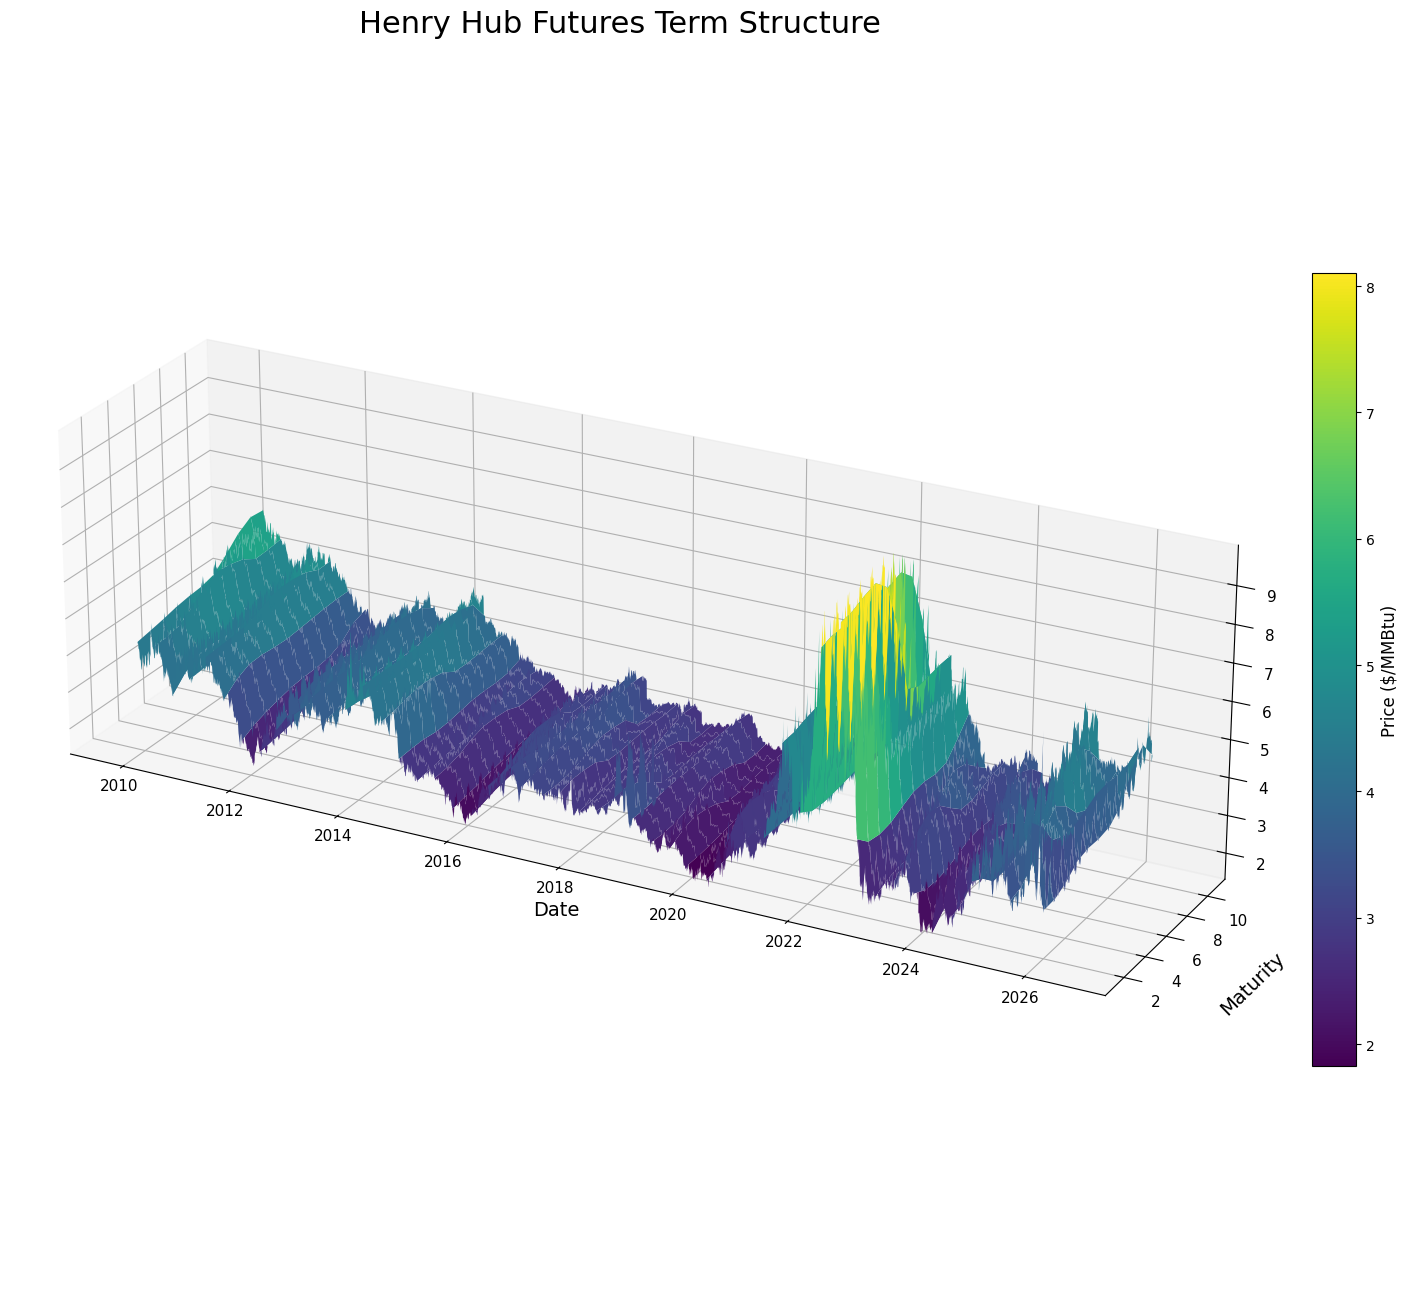

In [43]:
plot_henry_hub_3d(prices)

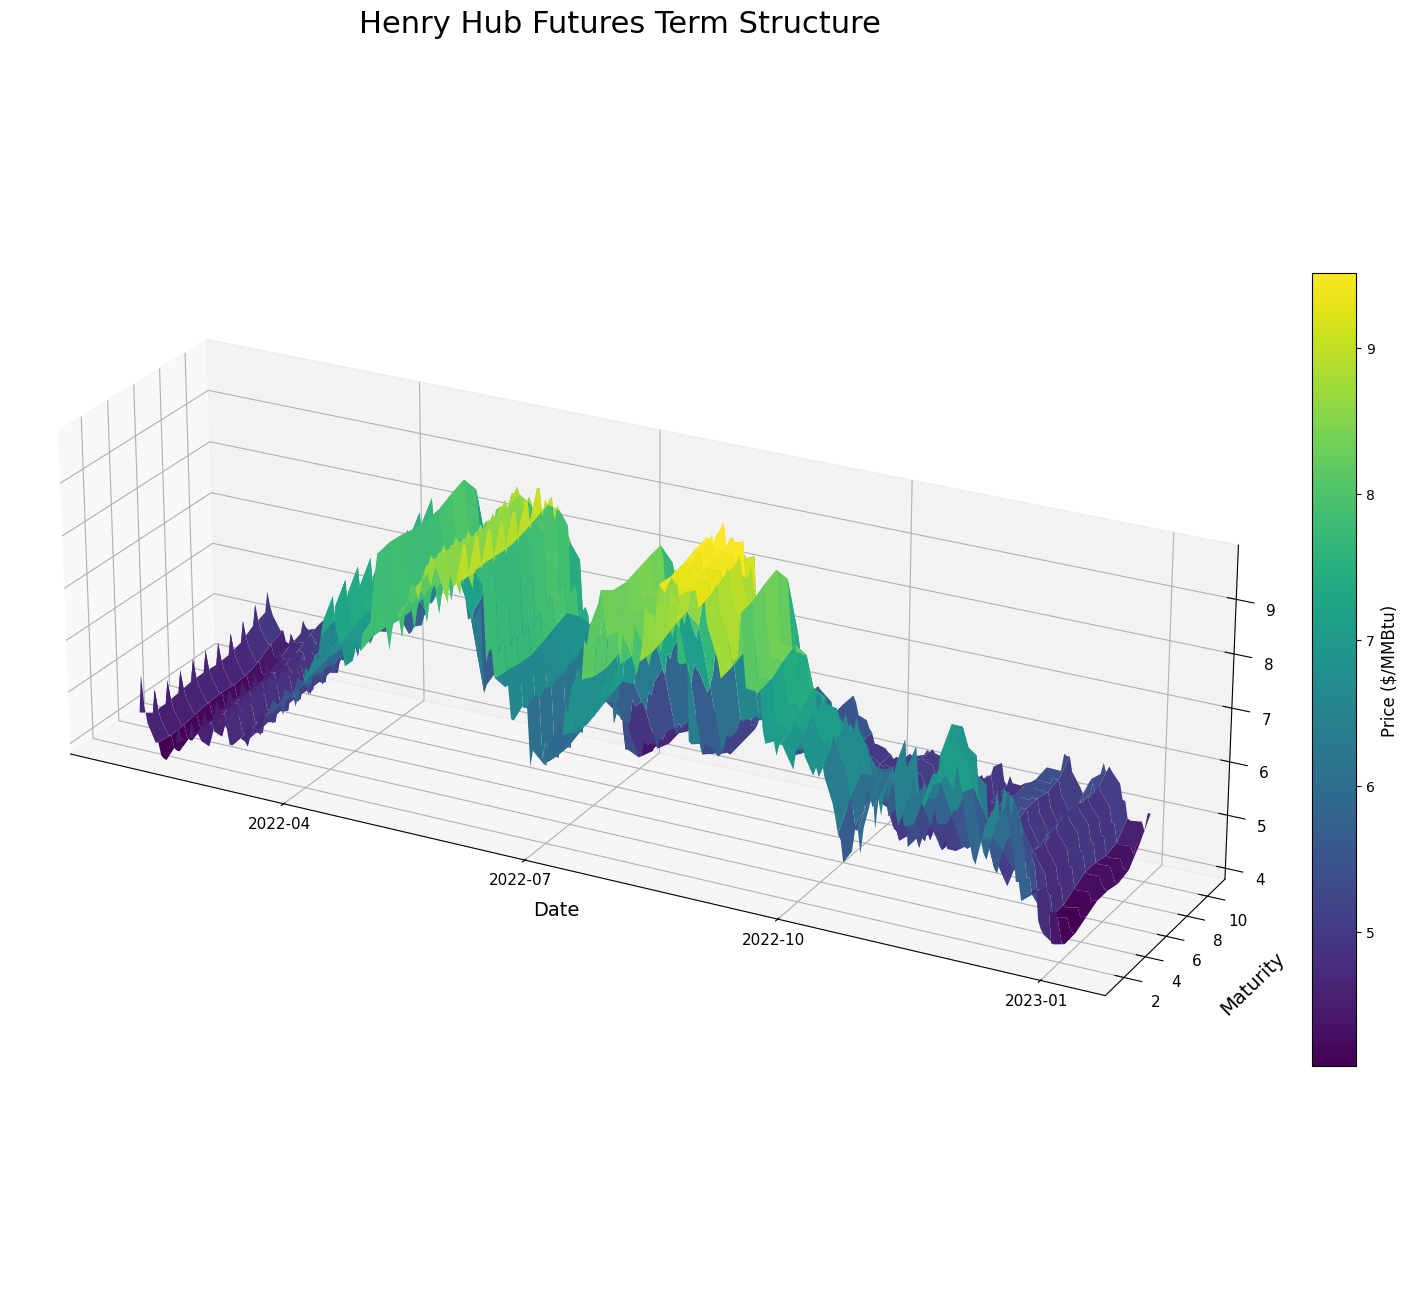

In [44]:
plot_henry_hub_3d(
    prices,
    start_date="2022-02-01",
    end_date="2022-12-31"
)

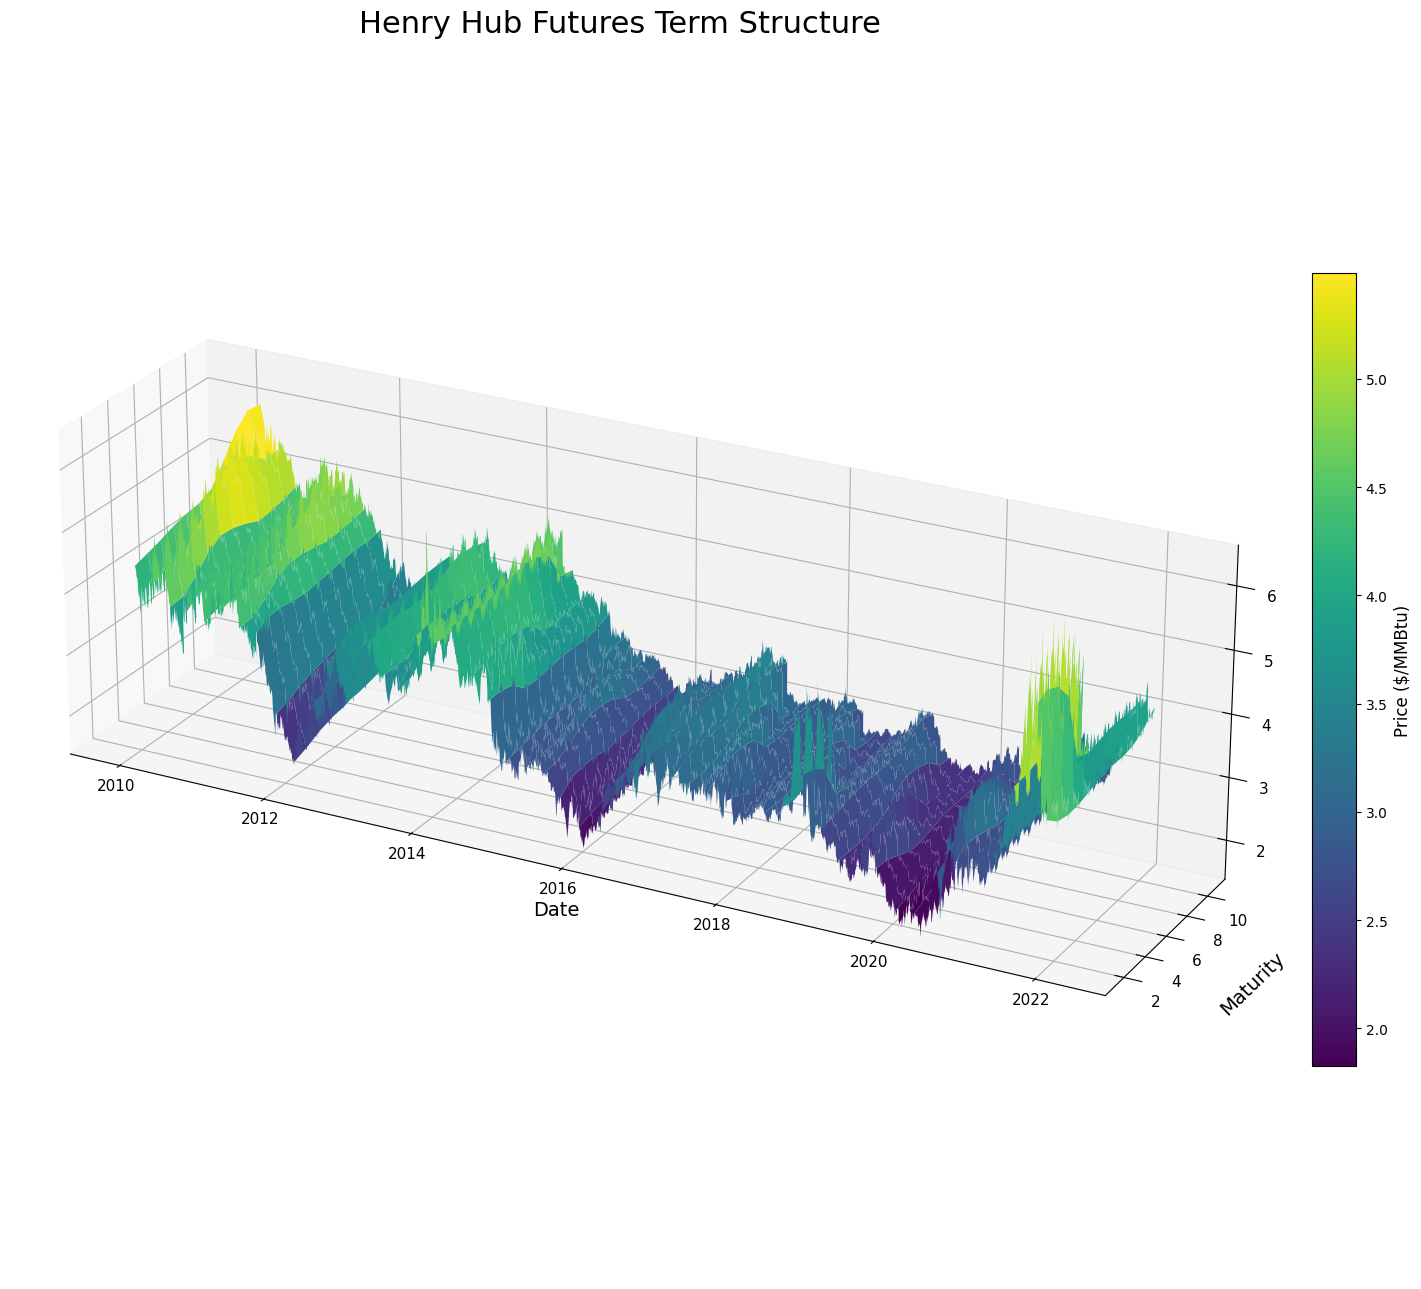

In [45]:
plot_henry_hub_3d(
    prices,
    end_date="2022-01-01"
)

Event	Date
- Polar vortex (US gas spike)	2014-01
- COVID crash	2020-03
- Texas freeze	2021-02
- Ukraine war	2022-02
- Energy crisis EU peak	2022-08

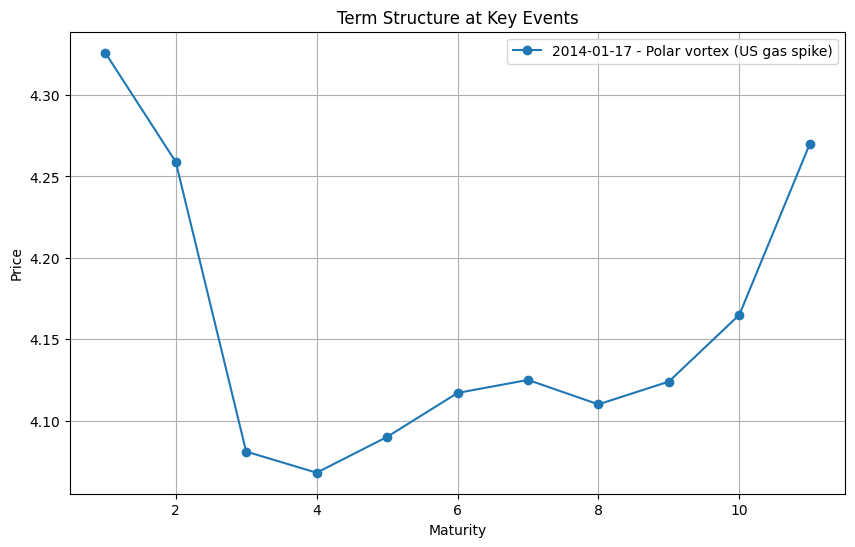

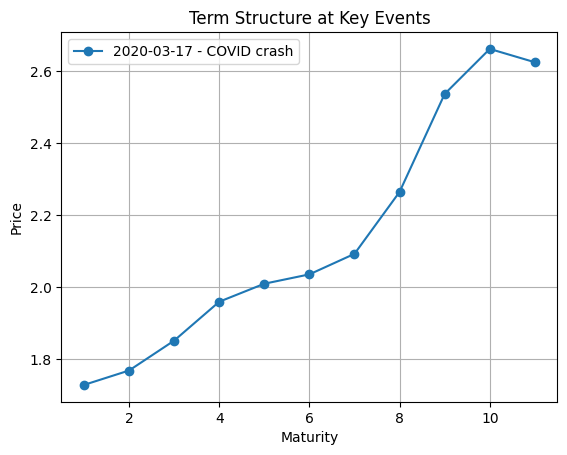

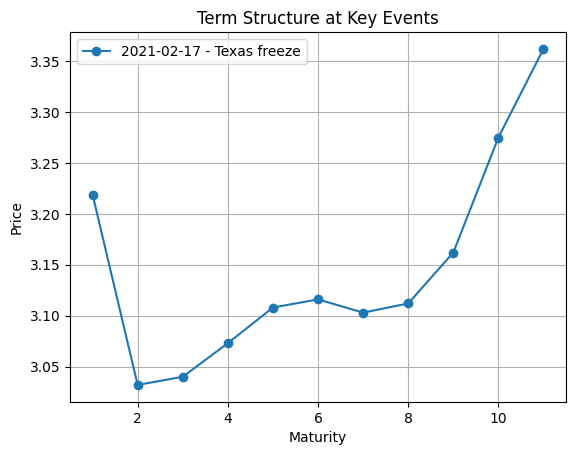

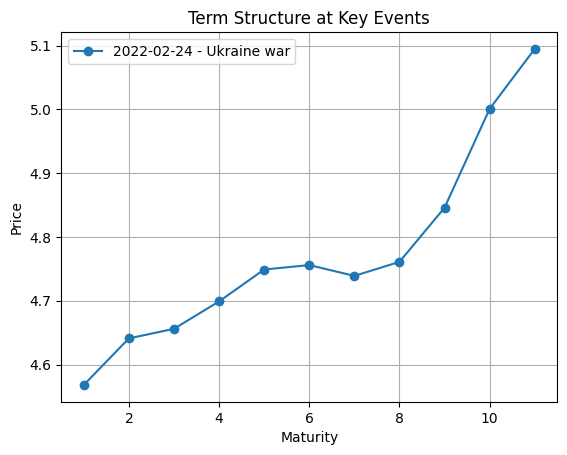

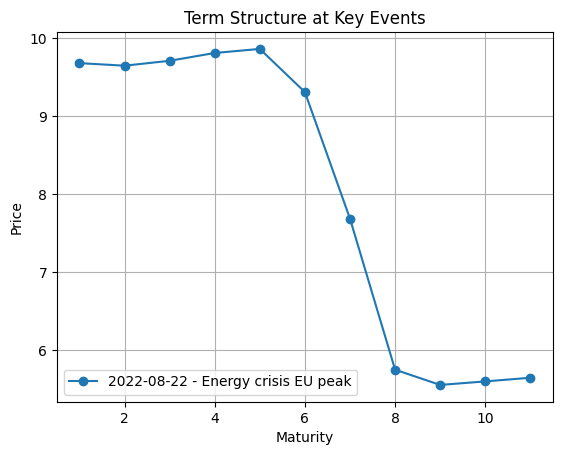

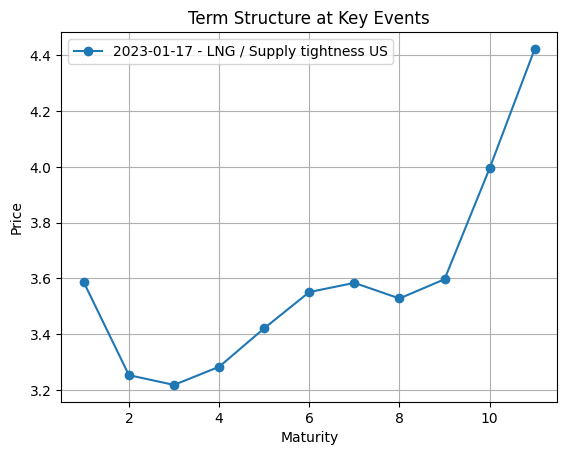

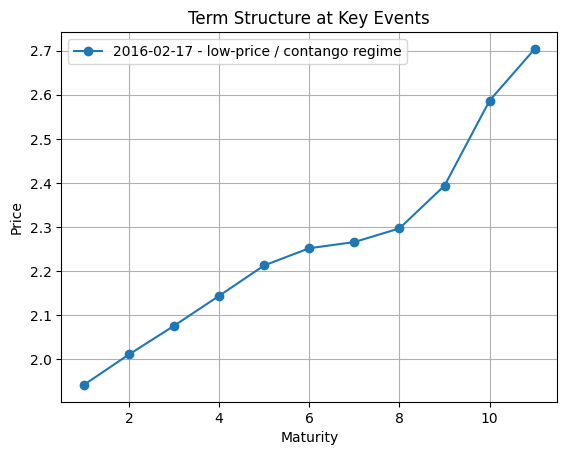

In [46]:
event_dates = {
    "2014-01-17": "Polar vortex (US gas spike)",
    "2020-03-17": "COVID crash",
    "2021-02-17": "Texas freeze",
    "2022-02-24": "Ukraine war",
    "2022-08-22": "Energy crisis EU peak",
    "2023-01-17": "LNG / Supply tightness US",
    "2016-02-17": "low-price / contango regime"

}

plt.figure(figsize=(10,6))

for d in event_dates:
    # trouver la date la plus proche dispo
    idx = (prices["Date"] - pd.to_datetime(d)).abs().idxmin()
    row = prices.loc[idx]

    plt.plot(
        range(1, len(price_cols)+1),
        row[price_cols],
        marker='o',
        label=str(row["Date"].date()) + " - " + event_dates[d]
    )

    plt.xlabel("Maturity")
    plt.ylabel("Price")
    plt.title("Term Structure at Key Events")
    plt.legend()
    plt.grid(True)
    plt.show()

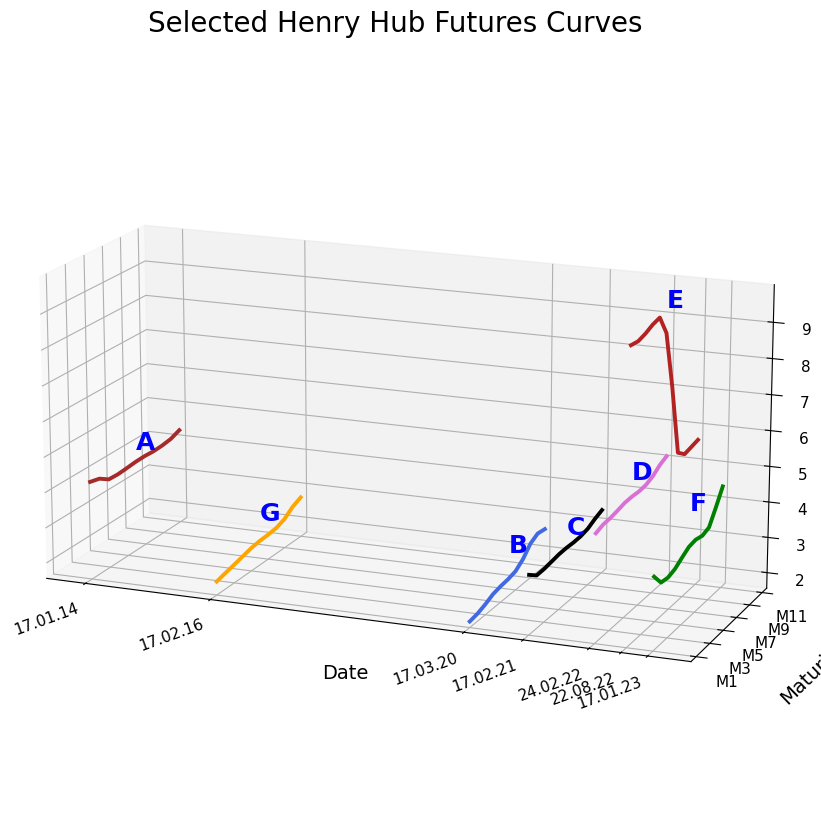

In [47]:

prices = prices.copy()
prices["Date"] = pd.to_datetime(prices["Date"]).dt.normalize()

maturities = np.arange(1, len(price_cols) + 1)

# =========================================
# 3. Récupération exacte des lignes
# =========================================
selected_rows = []

for d, desc in event_dates.items():
    d = pd.to_datetime(d).normalize()
    row = prices.loc[prices["Date"] == d]

    if row.empty:
        print(f"[WARNING] Date absente du dataset: {d.date()}")
        continue

    row = row.iloc[0]
    curve = row[price_cols].astype(float).values
    selected_rows.append((d, desc, curve))

# =========================================
# 4. Plot 3D
# =========================================
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, projection="3d")

colors = ["brown", "royalblue", "black", "orchid", "firebrick", "green", "orange"]

x_ticks = []
x_ticklabels = []

for i, (d, desc, curve) in enumerate(selected_rows):
    x_val = mdates.date2num(d)
    x = np.full(len(maturities), x_val)
    y = maturities
    z = curve

    ax.plot(
        x, y, z,
        color=colors[i % len(colors)],
        linewidth=2.8
    )

    # annotation courte
    ax.text(
        x_val,
        maturities[len(maturities) // 2],
        np.max(z) + 0.15,
        chr(65 + i),   # A, B, C...
        color="blue",
        fontsize=18,
        fontweight="bold"
    )

    x_ticks.append(x_val)
    x_ticklabels.append(d.strftime("%d.%m.%y"))

# =========================================
# 5. Axes
# =========================================
ax.set_xlabel("Date", labelpad=20, fontsize=14)
ax.set_ylabel("Maturity", labelpad=15, fontsize=14)
ax.set_zlabel("Price ($/MMBtu)", labelpad=25, fontsize=14)

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticklabels, rotation=20, ha="right")

ax.set_yticks([1, 3, 5, 7, 9, 11])
ax.set_yticklabels(["M1", "M3", "M5", "M7", "M9", "M11"])

ax.view_init(elev=16, azim=-68)
ax.set_box_aspect((4.8, 1.7, 2.2))

ax.tick_params(axis="x", labelsize=11, pad=5)
ax.tick_params(axis="y", labelsize=11, pad=5)
ax.tick_params(axis="z", labelsize=11, pad=5)

plt.title("Selected Henry Hub Futures Curves", fontsize=20, pad=20)
plt.show()

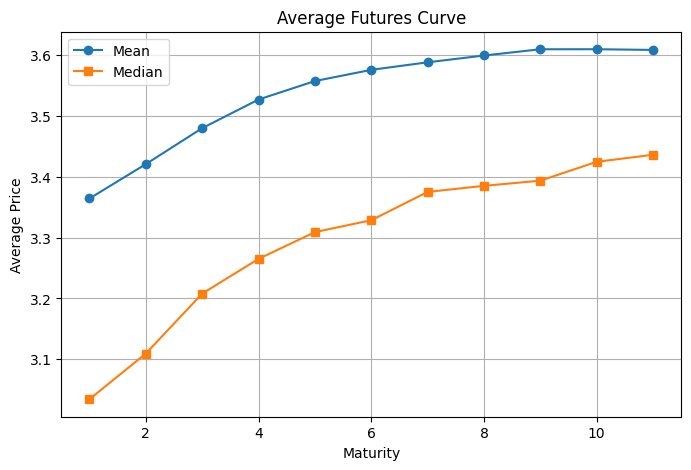

In [48]:
avg_curve = prices[price_cols].mean()
med_curve = prices[price_cols].median()
plt.figure(figsize=(8,5))
plt.plot(range(1, len(price_cols)+1), avg_curve, marker='o', label="Mean")
plt.plot(range(1, len(price_cols)+1), med_curve, marker='s', label="Median")
plt.xlabel("Maturity")
plt.ylabel("Average Price")
plt.legend()
plt.title("Average Futures Curve")
plt.grid(True)
plt.show()

In [49]:
price_cols

['hh_1',
 'hh_2',
 'hh_3',
 'hh_4',
 'hh_5',
 'hh_6',
 'hh_7',
 'hh_8',
 'hh_9',
 'hh_10',
 'hh_11']

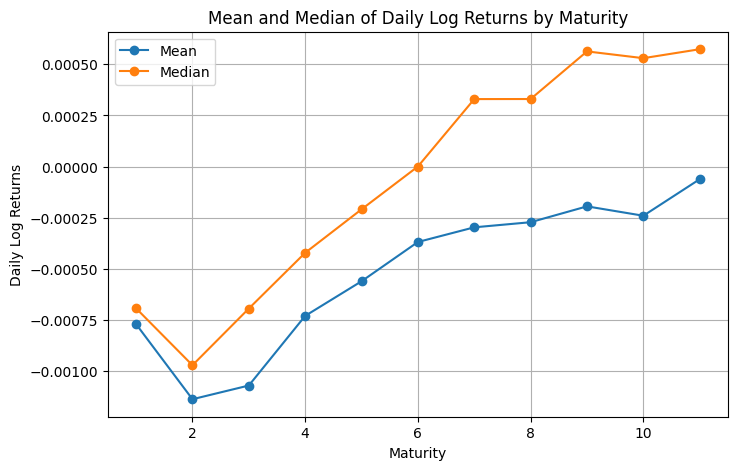

In [50]:
ret_mean = returns[price_cols].mean()
ret_median = returns[price_cols].median()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(price_cols)+1), ret_mean, marker='o', label="Mean")
plt.plot(range(1, len(price_cols)+1), ret_median, marker='o', label="Median")
plt.xlabel("Maturity")
plt.ylabel("Daily Log Returns")
plt.title("Mean and Median of Daily Log Returns by Maturity")
plt.legend()
plt.grid(True)
plt.show()

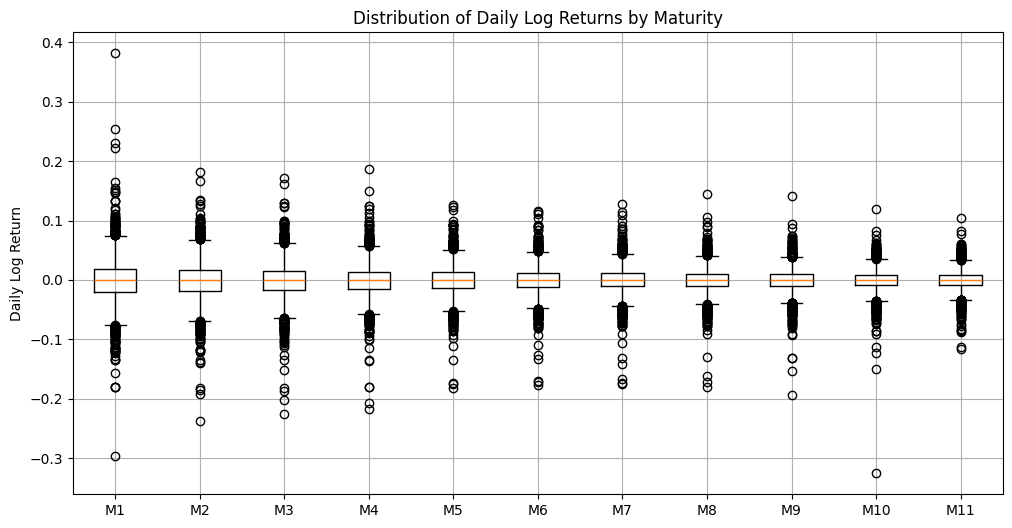

In [51]:
plt.figure(figsize=(12,6))
plt.boxplot([returns[col].dropna() for col in price_cols], labels=[f"M{i}" for i in range(1, len(price_cols)+1)])
plt.title("Distribution of Daily Log Returns by Maturity")
plt.ylabel("Daily Log Return")
plt.grid(True)
plt.show()

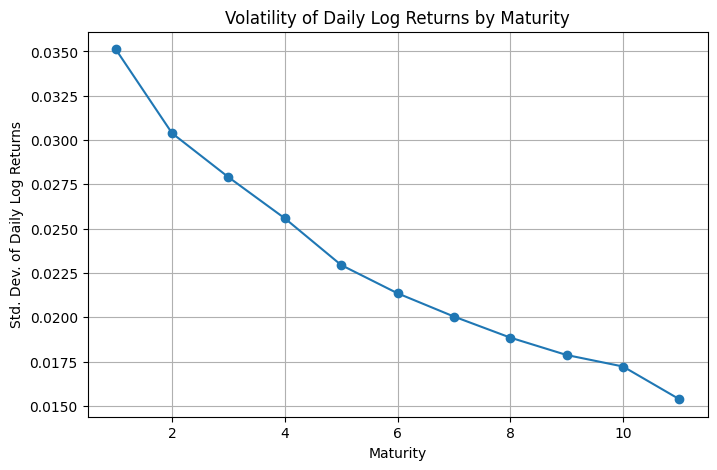

In [52]:
ret_vol = returns[price_cols].std()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(price_cols)+1), ret_vol, marker='o')
plt.xlabel("Maturity")
plt.ylabel("Std. Dev. of Daily Log Returns")
plt.title("Volatility of Daily Log Returns by Maturity")
plt.grid(True)
plt.show()

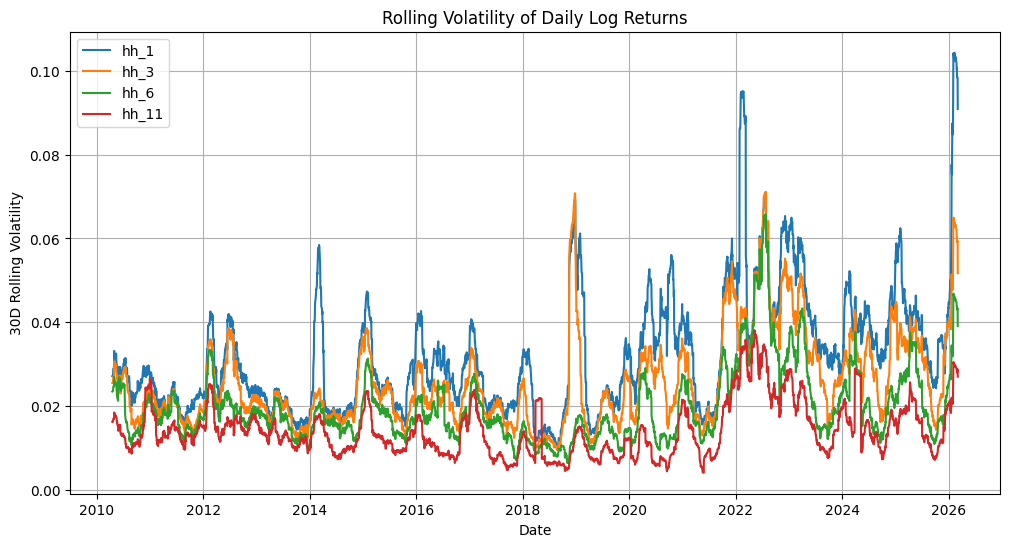

In [55]:
rolling_window = 30

rolling_vol = returns.set_index("Date")[ret_cols_raw].rolling(rolling_window).std()

sel_cols = ["hh_1", "hh_3", "hh_6", "hh_11"]

plt.figure(figsize=(12,6))
for col in sel_cols:
    plt.plot(rolling_vol.index, rolling_vol[col], label=col)

plt.xlabel("Date")
plt.ylabel(f"{rolling_window}D Rolling Volatility")
plt.title("Rolling Volatility of Daily Log Returns")
plt.legend()
plt.grid(True)
plt.show()

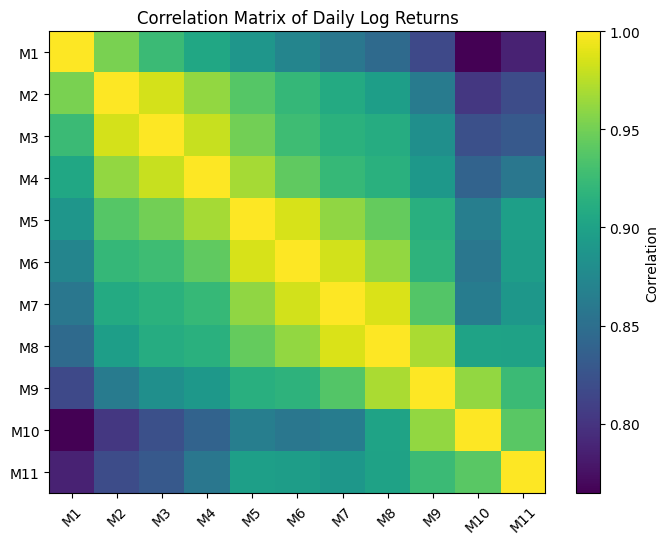

In [56]:
corr_mat = returns[price_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_mat, cmap="viridis", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(price_cols)), [f"M{i}" for i in range(1, len(price_cols)+1)], rotation=45)
plt.yticks(range(len(price_cols)), [f"M{i}" for i in range(1, len(price_cols)+1)])
plt.title("Correlation Matrix of Daily Log Returns")
plt.show()

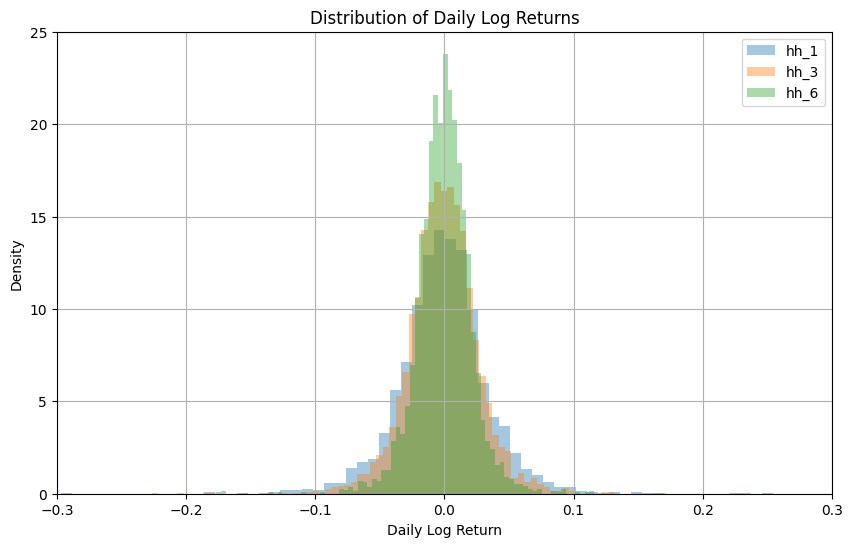

In [57]:
sel_cols = ["hh_1", "hh_3", "hh_6"]

plt.figure(figsize=(10,6))
for col in sel_cols:
    plt.hist(returns[col], bins=80, alpha=0.4, density=True, label=col)

plt.title("Distribution of Daily Log Returns")
plt.xlabel("Daily Log Return")
plt.ylabel("Density")
plt.xlim(-0.3, 0.3)
plt.legend()
plt.grid(True)
plt.show()

## 4. Outlier Detection and Winsorization

Following Paleologo: for each maturity i and date t, compute an asset-specific robust outlier score using only past returns (no look-ahead):

    d_{i,t} = |r_{i,t}| / median(|r_{i,t-1}|, ..., |r_{i,t-T}|)

Flag if d > d_max. Winsorize to `sign(r) × d_max × scale`. Genuine market events (coherent cross-maturity moves) are kept unchanged.

**Parameters:** T = 252, min_periods = 126, d_max = 10

In [58]:
returns_raw = returns.copy()
returns_raw

,Date,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,hh_10,hh_11
0,2010-03-05,0.003927,0.003440,0.002541,0.002909,0.003282,0.004071,0.003989,0.003753,0.004753,0.004572,0.004770
1,2010-03-08,-0.014474,-0.014921,-0.014913,-0.014629,-0.014231,-0.013703,-0.013426,-0.010734,-0.008289,-0.007972,-0.008020
2,2010-03-09,-0.002433,-0.003273,-0.003440,-0.003163,-0.003538,-0.004127,-0.004853,-0.006458,-0.006930,-0.007865,-0.008776
3,2010-03-10,0.009477,0.010653,0.011350,0.011340,0.011194,0.010286,0.009683,0.007215,0.005867,0.004282,0.004311
4,2010-03-11,-0.026449,-0.025850,-0.025230,-0.024734,-0.023148,-0.022352,-0.020895,-0.017365,-0.014823,-0.013421,-0.012293
...,...,...,...,...,...,...,...,...,...,...,...,...
4024,2026-02-26,-0.014399,-0.011496,-0.008198,-0.008105,-0.007914,-0.007652,-0.006951,-0.005373,-0.004391,-0.003843,-0.001906
4025,2026-02-27,0.011256,0.009416,0.008525,0.005710,0.005283,0.005597,0.006084,0.006177,0.004621,0.003630,0.004045
4026,2026-03-02,0.034717,0.035462,0.028325,0.022226,0.021718,0.022368,0.023410,0.027204,0.030869,0.031882,0.030865
4027,2026-03-03,0.031263,0.029705,0.024143,0.020882,0.020415,0.019910,0.020112,0.017306,0.026903,0.028492,0.025686


In [59]:
LOOKBACK = 252
MIN_PERIODS = 62
D_MAX = 10


def detect_outliers(
    returns_df,
    ret_cols,
    lookback=252,
    min_periods=126,
    d_max=10,
    neighbor_threshold=4,
):
    """
    Detect Paleologo-style return outliers without modifying the return matrix.

    scale_{i,t} = median(|r_{i,t-1}|, ..., |r_{i,t-lookback}|)
    d_{i,t}     = |r_{i,t}| / scale_{i,t}

    An observation is flagged if:

        d_{i,t} > d_max

    This function only creates a report. It does not winsorize returns.
    """

    r = returns_df[ret_cols].copy()
    abs_r = r.abs()

    # Strictly lagged rolling scale: no look-ahead bias.
    rolling_scale = (
        abs_r
        .shift(1)
        .rolling(window=lookback, min_periods=min_periods)
        .median()
    )

    score = abs_r / rolling_scale.replace(0, np.nan)
    r_max = d_max * rolling_scale

    report_rows = []

    for i, col in enumerate(ret_cols):
        has_scale = rolling_scale[col].notna()
        is_flagged = (score[col] > d_max) & has_scale

        prev_col = ret_cols[i - 1] if i > 0 else None
        next_col = ret_cols[i + 1] if i < len(ret_cols) - 1 else None

        for idx in r.index[is_flagged]:
            sc = rolling_scale.loc[idx, col]

            r_prev_mat = r.loc[idx, prev_col] if prev_col else np.nan
            r_next_mat = r.loc[idx, next_col] if next_col else np.nan
            r_prev_day = r.loc[idx - 1, col] if idx > r.index[0] else np.nan
            r_next_day = r.loc[idx + 1, col] if idx < r.index[-1] else np.nan

            # Preliminary local classification.
            # This is not the final decision.
            neighbor_large = any(
                abs(v) > neighbor_threshold * sc
                for v in [r_prev_mat, r_next_mat]
                if pd.notna(v)
            )

            if neighbor_large:
                auto_class = "likely_genuine_market_event"
                suggested_action = "keep_review"
            else:
                auto_class = "suspicious_isolated_outlier"
                suggested_action = "winsorize_review"

            report_rows.append({
                "date": returns_df.loc[idx, "Date"],
                "row_index": idx,
                "maturity": col,
                "r_original": r.loc[idx, col],
                "scale": sc,
                "score_d": score.loc[idx, col],
                "d_max": d_max,
                "r_max": r_max.loc[idx, col],
                "r_winsorized_candidate": np.sign(r.loc[idx, col]) * r_max.loc[idx, col],
                "r_prev_mat": r_prev_mat,
                "r_next_mat": r_next_mat,
                "r_prev_day": r_prev_day,
                "r_next_day": r_next_day,
                "auto_class": auto_class,
                "suggested_action": suggested_action,
                "manual_class": np.nan,
                "final_action": "review",
            })

    outlier_report = pd.DataFrame(report_rows)

    if not outlier_report.empty:
        outlier_report = outlier_report.sort_values(
            ["score_d", "date", "maturity"],
            ascending=[False, True, True],
        ).reset_index(drop=True)

    return outlier_report, score, rolling_scale

In [60]:
outlier_report, score_d, rolling_scale = detect_outliers(
    returns,
    price_cols,
    lookback=LOOKBACK,
    min_periods=MIN_PERIODS,
    d_max=D_MAX,
)

print(f"Total flagged observations: {len(outlier_report)}")

outlier_report

Total flagged observations: 38


,date,row_index,maturity,r_original,scale,score_d,d_max,r_max,r_winsorized_candidate,r_prev_mat,r_next_mat,r_prev_day,r_next_day,auto_class,suggested_action,manual_class,final_action
0,2018-11-15,2195,hh_4,-0.218014,0.009151,23.824658,10,0.091508,-0.091508,-0.202139,-0.033090,0.186265,0.072140,likely_genuine_market_event,keep_review,NaN,review
1,2021-05-27,2831,hh_10,-0.150008,0.006964,21.539236,10,0.069644,-0.069644,-0.077812,-0.029420,0.008558,0.025647,likely_genuine_market_event,keep_review,NaN,review
2,2022-05-27,3084,hh_10,-0.325734,0.015331,21.246749,10,0.153310,-0.153310,-0.193866,-0.038023,-0.012200,-0.016166,likely_genuine_market_event,keep_review,NaN,review
3,2018-11-14,2194,hh_4,0.186265,0.009151,20.355141,10,0.091508,0.091508,0.171313,0.017112,0.119772,-0.218014,likely_genuine_market_event,keep_review,NaN,review
4,2018-11-15,2195,hh_3,-0.202139,0.010175,19.866817,10,0.101747,-0.101747,-0.191840,-0.218014,0.171313,0.062419,likely_genuine_market_event,keep_review,NaN,review
5,2018-03-29,2034,hh_11,0.104797,0.005284,19.831171,10,0.052844,0.052844,0.038998,NaN,-0.035396,-0.006451,likely_genuine_market_event,keep_review,NaN,review
6,2022-01-27,3000,hh_1,0.381727,0.019903,19.179407,10,0.199029,0.199029,NaN,0.059400,0.053794,0.079845,suspicious_isolated_outlier,winsorize_review,NaN,review
7,2021-05-28,2832,hh_9,0.141780,0.007614,18.620383,10,0.076142,0.076142,0.066659,0.025647,-0.077812,0.028345,likely_genuine_market_event,keep_review,NaN,review
8,2018-11-15,2195,hh_2,-0.191840,0.010879,17.633618,10,0.108792,-0.108792,-0.180545,-0.202139,0.166442,0.059533,likely_genuine_market_event,keep_review,NaN,review
9,2018-11-14,2194,hh_3,0.171313,0.010175,16.837142,10,0.101747,0.101747,0.166442,0.186265,0.093570,-0.202139,likely_genuine_market_event,keep_review,NaN,review


In [61]:
outlier_report.groupby("maturity").size().sort_values(ascending=False)

maturity
hh_1     6
hh_4     6
hh_10    5
hh_11    4
hh_2     4
hh_9     4
hh_3     3
hh_7     2
hh_8     2
hh_5     1
hh_6     1
dtype: int64

In [62]:
outlier_report.groupby("date").size().sort_values(ascending=False).head(30)

date
2026-02-02    11
2018-11-14     4
2018-11-15     4
2019-01-14     2
2020-12-03     2
2021-05-27     2
2022-05-27     2
2024-03-27     2
2024-03-28     2
2014-11-26     1
2018-03-29     1
2018-11-13     1
2018-11-19     1
2019-01-22     1
2021-05-28     1
2022-01-27     1
dtype: int64

In [63]:
outlier_report["auto_class"].value_counts()

auto_class
likely_genuine_market_event    36
suspicious_isolated_outlier     2
Name: count, dtype: int64

In [64]:
outlier_report[outlier_report["auto_class"] == "suspicious_isolated_outlier"].groupby("maturity").size().sort_values(ascending=False)

maturity
hh_1    1
hh_4    1
dtype: int64

In [65]:
outlier_report[outlier_report["auto_class"] == "suspicious_isolated_outlier"]

,date,row_index,maturity,r_original,scale,score_d,d_max,r_max,r_winsorized_candidate,r_prev_mat,r_next_mat,r_prev_day,r_next_day,auto_class,suggested_action,manual_class,final_action
6,2022-01-27,3000,hh_1,0.381727,0.019903,19.179407,10,0.199029,0.199029,NaN,0.059400,0.053794,0.079845,suspicious_isolated_outlier,winsorize_review,NaN,review
24,2014-11-26,1194,hh_4,-0.135861,0.011525,11.788137,10,0.115252,-0.115252,-0.026156,-0.024561,0.019737,-0.026467,suspicious_isolated_outlier,winsorize_review,NaN,review


In [66]:
outlier_report["date"] = pd.to_datetime(outlier_report["date"])
outlier_report["manual_class"] = outlier_report["manual_class"].astype("object")
outlier_report["final_action"] = outlier_report["final_action"].astype("object")


likely_market_event_dates = pd.to_datetime([
    "2022-01-27",
    "2022-01-28",
    "2026-01-27",
    "2026-01-28",
    "2026-01-29",
    "2014-11-26",
])

mask_market_event = outlier_report["date"].isin(likely_market_event_dates)

outlier_report.loc[mask_market_event, "manual_class"] = "likely_genuine_market_event"
outlier_report.loc[mask_market_event, "final_action"] = "keep"


mask_suspicious = (
    outlier_report["auto_class"].eq("suspicious_isolated_outlier")
    & outlier_report["final_action"].eq("review")
)

outlier_report.loc[mask_suspicious, "manual_class"] = "suspicious_isolated_outlier"
outlier_report.loc[mask_suspicious, "final_action"] = "winsorize"


mask_remaining = outlier_report["final_action"].eq("review")

outlier_report.loc[mask_remaining, "manual_class"] = "not_manually_reviewed_likely_market_event"
outlier_report.loc[mask_remaining, "final_action"] = "keep"

In [67]:
outlier_report[outlier_report["manual_class"] == "suspicious_isolated_outlier"]

,date,row_index,maturity,r_original,scale,score_d,d_max,r_max,r_winsorized_candidate,r_prev_mat,r_next_mat,r_prev_day,r_next_day,auto_class,suggested_action,manual_class,final_action


In [68]:
outlier_report

,date,row_index,maturity,r_original,scale,score_d,d_max,r_max,r_winsorized_candidate,r_prev_mat,r_next_mat,r_prev_day,r_next_day,auto_class,suggested_action,manual_class,final_action
0,2018-11-15,2195,hh_4,-0.218014,0.009151,23.824658,10,0.091508,-0.091508,-0.202139,-0.033090,0.186265,0.072140,likely_genuine_market_event,keep_review,not_manually_reviewed_likely_market_event,keep
1,2021-05-27,2831,hh_10,-0.150008,0.006964,21.539236,10,0.069644,-0.069644,-0.077812,-0.029420,0.008558,0.025647,likely_genuine_market_event,keep_review,not_manually_reviewed_likely_market_event,keep
2,2022-05-27,3084,hh_10,-0.325734,0.015331,21.246749,10,0.153310,-0.153310,-0.193866,-0.038023,-0.012200,-0.016166,likely_genuine_market_event,keep_review,not_manually_reviewed_likely_market_event,keep
3,2018-11-14,2194,hh_4,0.186265,0.009151,20.355141,10,0.091508,0.091508,0.171313,0.017112,0.119772,-0.218014,likely_genuine_market_event,keep_review,not_manually_reviewed_likely_market_event,keep
4,2018-11-15,2195,hh_3,-0.202139,0.010175,19.866817,10,0.101747,-0.101747,-0.191840,-0.218014,0.171313,0.062419,likely_genuine_market_event,keep_review,not_manually_reviewed_likely_market_event,keep
5,2018-03-29,2034,hh_11,0.104797,0.005284,19.831171,10,0.052844,0.052844,0.038998,NaN,-0.035396,-0.006451,likely_genuine_market_event,keep_review,not_manually_reviewed_likely_market_event,keep
6,2022-01-27,3000,hh_1,0.381727,0.019903,19.179407,10,0.199029,0.199029,NaN,0.059400,0.053794,0.079845,suspicious_isolated_outlier,winsorize_review,likely_genuine_market_event,keep
7,2021-05-28,2832,hh_9,0.141780,0.007614,18.620383,10,0.076142,0.076142,0.066659,0.025647,-0.077812,0.028345,likely_genuine_market_event,keep_review,not_manually_reviewed_likely_market_event,keep
8,2018-11-15,2195,hh_2,-0.191840,0.010879,17.633618,10,0.108792,-0.108792,-0.180545,-0.202139,0.166442,0.059533,likely_genuine_market_event,keep_review,not_manually_reviewed_likely_market_event,keep
9,2018-11-14,2194,hh_3,0.171313,0.010175,16.837142,10,0.101747,0.101747,0.166442,0.186265,0.093570,-0.202139,likely_genuine_market_event,keep_review,not_manually_reviewed_likely_market_event,keep


In [69]:
def apply_winsorization_from_report(
    returns_df,
    outlier_report,
    action_col="final_action",
):
    """
    Apply decisions from outlier_report.

    Supported actions:
        - keep
        - winsorize
        - remove

    The dataframe outlier_report must contain:
        - row_index
        - maturity
        - r_winsorized_candidate
        - final_action
    """

    returns_clean = returns_df.copy()
    treatment_rows = []

    for _, row in outlier_report.iterrows():
        idx = int(row["row_index"])
        col = row["maturity"]
        action = row[action_col]

        old_value = returns_clean.loc[idx, col]

        if action == "keep":
            new_value = old_value

        elif action == "winsorize":
            new_value = row["r_winsorized_candidate"]
            returns_clean.loc[idx, col] = new_value

        elif action == "remove":
            new_value = np.nan
            returns_clean.loc[idx, col] = np.nan

        else:
            raise ValueError(f"Unknown action: {action}")

        treatment_rows.append({
            "date": row["date"],
            "row_index": idx,
            "maturity": col,
            "action": action,
            "r_original": row["r_original"],
            "r_before_treatment": old_value,
            "r_after_treatment": new_value,
            "score_d": row["score_d"],
            "scale": row["scale"],
            "auto_class": row["auto_class"],
            "manual_class": row["manual_class"],
        })

    treatment_log = pd.DataFrame(treatment_rows)

    return returns_clean, treatment_log

In [70]:
returns_win_suspicious_only, treatment_log_suspicious = apply_winsorization_from_report(
    returns_df=returns_raw,
    outlier_report=outlier_report,
    action_col="final_action",
)

In [71]:
treatment_log_suspicious["action"].value_counts()

action
keep    38
Name: count, dtype: int64

In [72]:
treatment_log_suspicious[treatment_log_suspicious["action"] == "winsorize"].head(30)

,date,row_index,maturity,action,r_original,r_before_treatment,r_after_treatment,score_d,scale,auto_class,manual_class


In [73]:
treatment_log_suspicious[
    np.sign(treatment_log_suspicious["r_after_treatment"])
    != np.sign(treatment_log_suspicious["r_original"])
]

,date,row_index,maturity,action,r_original,r_before_treatment,r_after_treatment,score_d,scale,auto_class,manual_class


In [74]:
print("Raw shape:", returns_raw.shape)
print("Suspicious-only shape:", returns_win_suspicious_only.shape)

print("\nSuspicious-only treatment:")
print(treatment_log_suspicious["action"].value_counts())


Raw shape: (4029, 12)
Suspicious-only shape: (4029, 12)

Suspicious-only treatment:
action
keep    38
Name: count, dtype: int64


In [75]:
returns_raw.to_csv("data/HHub/returns_raw.csv", index=False)
returns_win_suspicious_only.to_csv("data/HHub/returns_clean.csv", index=False)

outlier_report.to_csv("data/HHub/outlier_report.csv", index=False)
treatment_log_suspicious.to_csv("data/HHub/outlier_treatment_log_suspicious.csv", index=False)